# Tutorial 2 — two IRDIS channels as partitions: HD 95086 b (VLT/SPHERE, K1/K2)

Ground-based data usually come in several pieces that could be reduced together or
apart: nights, epochs, the two IRDIS dual-band channels, IFS channels, chop states, the
pyNOMIC *image groups*.  klip-tpe calls each such piece a **partition**.  Every
partition gets its own KLIP basis and its own parameter block, and the optimizer also
searches *which* partitions to combine (the `drop1`/`drop2` dimensions) — a partition
that hurts the combined S/N gets dropped, one that helps stays.

Here the two channels of a SPHERE/IRDIS DB_K12 sequence of HD 95086 (63 frames each,
33.8° of field rotation, 2019-04-13) are the partitions.  HD 95086 b (0.62″, PA ≈ 145°)
is a real, faint (ΔK ≈ 12 mag) companion — a good test that the *validated* winner
does better than the default on a real signal rather than on injected ones only.

The 241×241 px crops (0.01225″/px, star at the centre) and the unsaturated flux frames
are fetched from the klip-tpe GitHub release (`datasets.fetch("sphere_hd95086")`).

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay
from klip_tpe.reducer import ReductionRequest

RUN_DIR = os.path.abspath("runs/hd95086_irdis")
# Re-running RESUMES this directory -- delete it to search again (see tutorial 01).
files = datasets.fetch("sphere_hd95086")
inst = datasets.INSTRUMENT["sphere_hd95086"]
files, inst

({'cube_K1': '/root/.klip_tpe/data/hd95086_irdis_K1_cube.fits',
  'cube_K2': '/root/.klip_tpe/data/hd95086_irdis_K2_cube.fits',
  'psf_K1': '/root/.klip_tpe/data/hd95086_irdis_K1_psf.fits',
  'psf_K2': '/root/.klip_tpe/data/hd95086_irdis_K2_psf.fits',
  'angles': '/root/.klip_tpe/data/hd95086_irdis_angles.fits'},
 {'pxscale': 0.01225,
  'lam_m': 2.11e-06,
  'lam_m_K2': 2.251e-06,
  'diam_m': 8.2,
  'truenorth': 0.0,
  'dit_science': 96.0,
  'dit_flux': 0.837464,
  'nd_transmission': 0.0851})

## 1. Two partitions, one star flux per channel

Injected companions are expressed as a *contrast*, so the reducer needs the star's flux
**in the science frames' own units**.  The flux frames here were taken with DIT 0.837 s
through the ND_1.0 filter and the science frames with DIT 96 s and no ND — but **these
products already carry that correction**, so the star flux is the flux frame's own sum
and nothing further.

Getting this wrong is invisible to the optimizer and fatal to the contrast axis, because
the search only ever compares S/N.  Applying `(96/0.837)/T_ND ≈ 1347` a second time put
the injections at 3.21e-09 for S/N 4.8 while HD 95086 b sat at S/N 12.2 in the same
image — an implied planet contrast of 8.1e-09 against a published ΔK1 = 12.2 mag, i.e.
1.3e-05.  The ratio is 1625: the factor, within the accuracy of reading one off the
other.  Removing it gives 1.1e-05.  **Check any star flux against a known companion
before you believe a contrast curve.**

Each channel has its own wavelength (2.110 / 2.251 µm), hence its own λ/D and FWHM —
`make_reducer` takes per-partition dicts.

In [2]:
angles = fits.getdata(files["angles"])
dsets, star_flux, lam = {}, {}, {}
# The flux frames in this distribution are ALREADY on the science frames' scale -- the
# DIT ratio and the ND transmission were applied when the products were made -- so the
# star flux is the flux frame's own sum and nothing more.  Applying
# `dit_science/dit_flux/nd_transmission` here as well over-counted the star by 1347x and
# pushed the whole contrast axis down by that factor: the injections calibrated to 3.21e-09
# for S/N 4.8 while HD 95086 b sat at S/N 12.2 in the same image, implying a planet contrast
# of 8.1e-09 against a published dK1 = 12.2 mag, i.e. 1.3e-05.  The ratio, 1625, is that
# factor.  Without it the implied contrast is 1.1e-05 -- the published value.
for band in ("K1", "K2"):
    ds = generic.load_cube(files[f"cube_{band}"], angles, psf=files[f"psf_{band}"], name=band)
    dsets[band] = ds
    psf = ds.meta["psf"]
    star_flux[band] = float(psf[psf > 0].sum())
    lam[band] = inst["lam_m"] if band == "K1" else inst["lam_m_K2"]
    print(f"{band}: {ds.cube.shape}, PA {ds.angles.min():.1f}..{ds.angles.max():.1f} deg, star flux {star_flux[band]:.3g}")

red = generic.make_reducer(dsets, pxscale=inst["pxscale"], lam_m=lam, diam_m=inst["diam_m"], star_flux=star_flux,
                           max_workers="auto")
space = generic.make_space(red, k_klip_max=30)      # ranges scaled to the data (<=30 KL modes, <=7 frames/bin)
space.project = generic.make_guard(red, k_max=30)
objective, sampler = generic.default_config(red, known=[(0.62, 145.0)])     # keep injections off the planet
print(space.names)

K1: (63, 241, 241), PA 122.5..156.3 deg, star flux 2.16e+06


K2: (63, 241, 241), PA 122.5..156.3 deg, star flux 2.47e+06
  K1: 63 frames 241x241 px, PA span 33.8 deg, injection template (flux unit 2.16e+06), fwhm 4.45 px, lambda/D 4.33 px
  K2: 63 frames 241x241 px, PA span 33.8 deg, injection template (flux unit 2.47e+06), fwhm 4.75 px, lambda/D 4.62 px
['bin_K1', 'n_ang_K1', 'filter_K1', 'angsep_K1', 'anglemax_K1', 'corr_thresh_K1', 'noise_max_K1', 'coronoise_max_K1', 'k_klip_K1', 'bin_K2', 'n_ang_K2', 'filter_K2', 'angsep_K2', 'anglemax_K2', 'corr_thresh_K2', 'noise_max_K2', 'coronoise_max_K2', 'k_klip_K2', 'drop1', 'drop2']


`space.names` shows the structure: one block of nine parameters per channel
(`bin_K1 … k_klip_K1`, `bin_K2 … k_klip_K2`) plus the two selection slots.  A default
reduction of the 30–70 px (0.37–0.86″) annulus recovers the planet in both channels:

  parallel: 2 workers on 2 cores: injected + clean reductions concurrent, 2 partition jobs in parallel, 1 target thread(s) per partition job; pool = processes


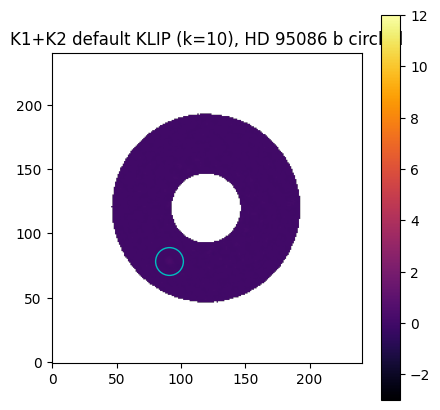

In [3]:
cfg0 = space.decode(space.default_vector())
res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=30, outrad=70, k_klip=10)))
c = 120; rho = 0.62 / inst["pxscale"]; pa = np.deg2rad(145.0)
xb, yb = c - rho * np.sin(pa), c + rho * np.cos(pa)
plt.figure(figsize=(5, 5)); plt.imshow(res.image, origin="lower", cmap="inferno", vmin=-3, vmax=12)
plt.plot(xb, yb, "o", mfc="none", mec="c", ms=20); plt.title("K1+K2 default KLIP (k=10), HD 95086 b circled"); plt.colorbar();

## 2. Optimize

80 evaluations (20 warm-up), the best two validated on three fresh injection sets each,
on the 30–70 px annulus.  On a laptop this takes ~10 minutes; most of it is the live
panel, `display_every=2` halves that.  The contrast is calibrated to S/N ≈ 5 for the
default configuration.

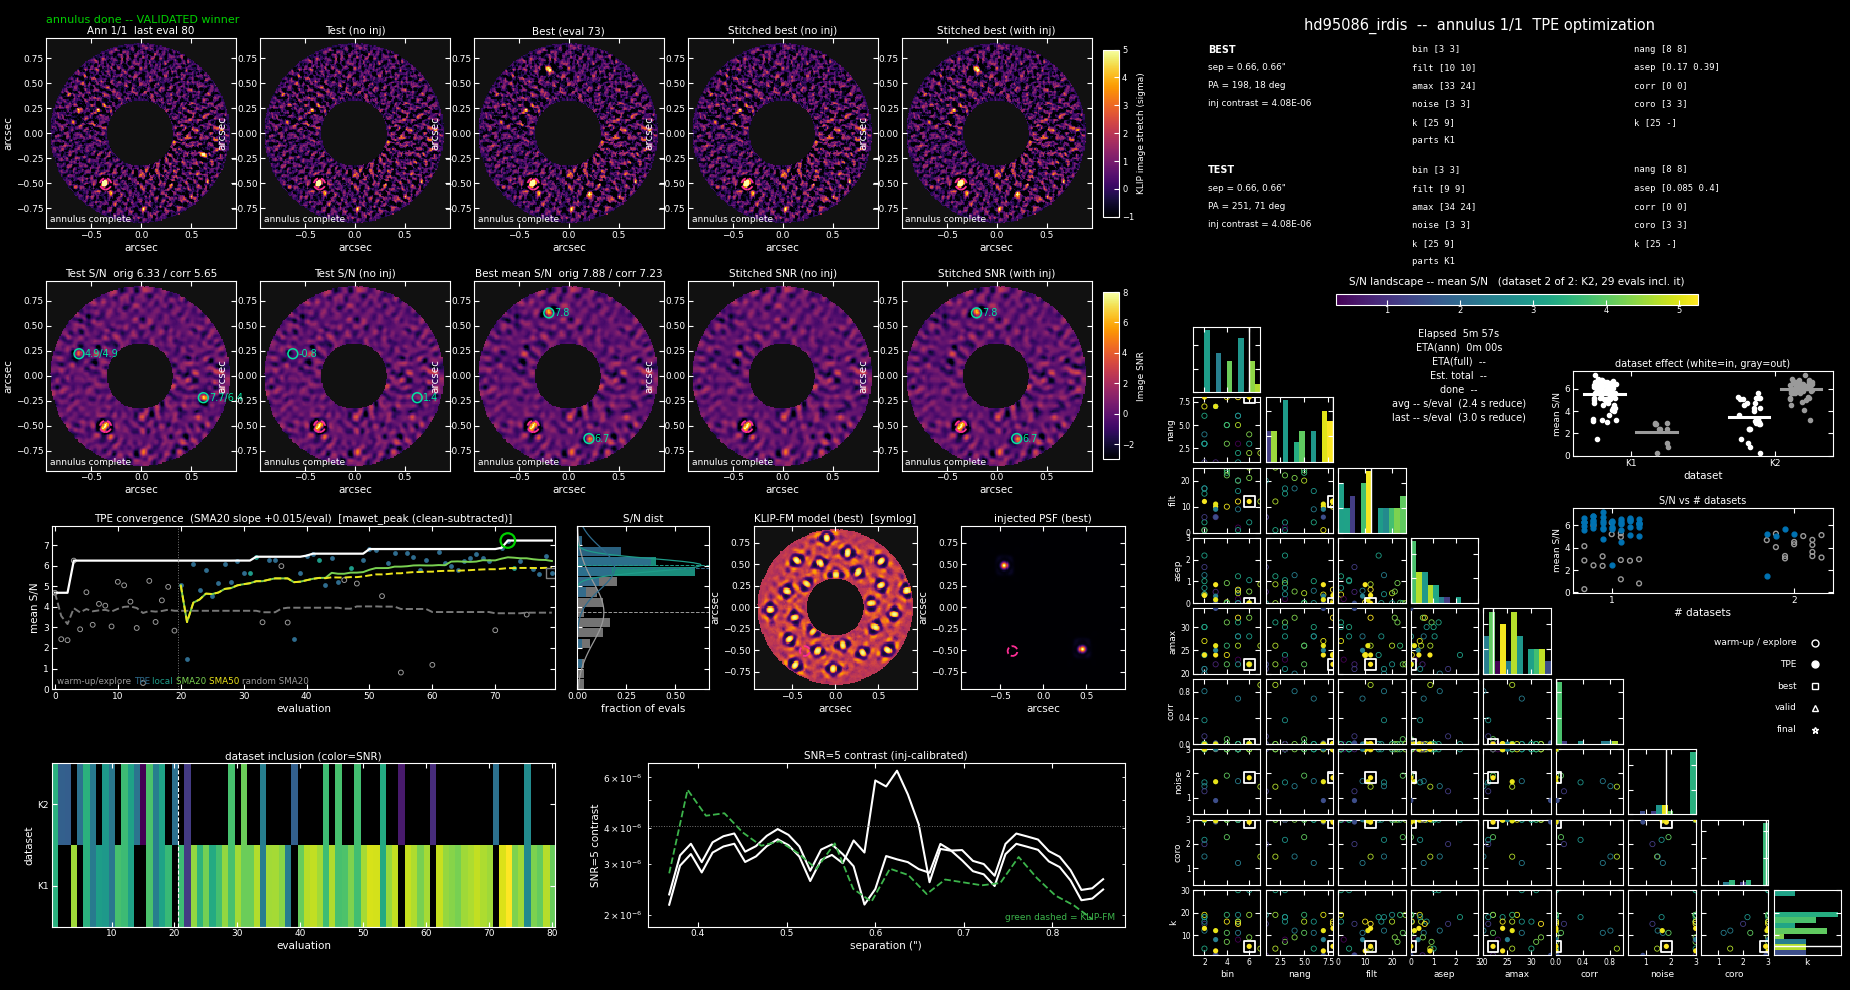

=== annulus 1/1: [30.0, 70.0] px, 2 sources, band 0.660-0.660"


  calibration k-scan: k_default = 4


  calibration trial 1: contrast=3.000e-05  median S/N=15.39


  calibration trial 2: contrast=9.749e-06  median S/N=9.85


  calibration trial 3: contrast=4.947e-06  median S/N=5.87


...

param_verify config 19/20 (eval 46, score 5.20)


param_verify config 20/20 (eval 27, score 5.15)


param_verify annulus 01: 20 configs; combine K~1.668E+04


run complete: 1 annuli, 90 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/hd95086_irdis/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/hd95086_irdis/opt_steps.mp4']
6.4 min


In [4]:
cfg = RunConfig(ann_edges=[30, 70], n_iter=80, n_init=20, seed=3,
                validation=ValidationConfig(n_top=2, n_valid=3),
                calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                defaults={"k_klip": 10}, fm_curve=True)
display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, every=2, movie_every=10)
runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
t0 = time.time(); results = runner.run(); print(f"{(time.time() - t0) / 60:.1f} min")

## 3. What did it decide?

Besides the winner's parameters, the interesting outputs for partitions are: which
channels the winner keeps, the *night effect* panel (median S/N with each partition in
vs out), and the per-partition images in `products.pdf`.

Both channels were tuned, but the selection slots decide what enters the combination:
in this run only K1 survives — K2's speckle residuals cost the combined image more than
its photons add at this separation.  That is the decision you would otherwise make by
hand, made on the validated injection S/N instead.

In [5]:
r = results[0]
print(f"winner: eval {r.winner_index + 1}, validated {r.validated}, S/N {r.winner_score:.2f}  (search best {r.search_best_score:.2f})")
print("partitions kept:", r.partitions, " of", list(dsets))
for pid, blk in r.winner_config["per_partition"].items():                      # every block, kept or not
    keep = "kept   " if pid in r.partitions else "dropped"
    print(f"  {pid} ({keep}): " + "  ".join(f"{k}={v:.3g}" if isinstance(v, float) else f"{k}={v}"
                                            for k, v in blk.items() if k not in ("spat_mean", "temp_mean")))

winner: eval 73, validated True, S/N 7.24  (search best 7.23)
partitions kept: ['K1']  of ['K1', 'K2']
  K1 (kept   ): bin=3  n_ang=8  filter=10  angsep=0.171  anglemax=33  corr_thresh=0  noise_max=3  coronoise_max=3  k_klip=25
  K2 (dropped): bin=3  n_ang=8  filter=10  angsep=0.385  anglemax=24  corr_thresh=0  noise_max=3  coronoise_max=3  k_klip=9


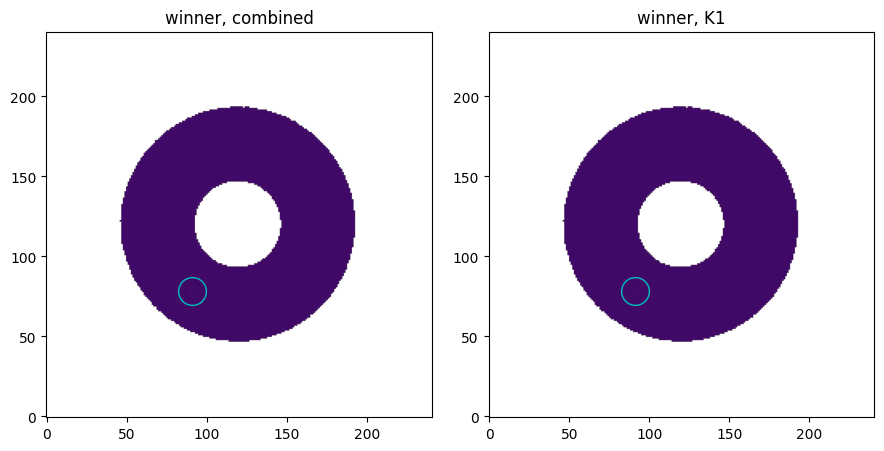

In [6]:
best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
parts = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean_partitions.fits"))
parts = parts[None] if parts.ndim == 2 else parts                              # one kept partition -> (ny, nx)
fig, ax = plt.subplots(1, 1 + parts.shape[0], figsize=(4.5 * (1 + parts.shape[0]), 4.4), squeeze=False)
ax = ax.ravel()
ax[0].imshow(best_clean, origin="lower", cmap="inferno", vmin=-3, vmax=12); ax[0].set_title("winner, combined")
for a_, im, pid in zip(ax[1:], parts, r.partitions):
    a_.imshow(im, origin="lower", cmap="inferno", vmin=-3, vmax=12); a_.set_title(f"winner, {pid}")
for a_ in ax:
    a_.plot(xb, yb, "o", mfc="none", mec="c", ms=20)
plt.tight_layout()

The planet's S/N in the default versus the optimized reduction, measured the same way
the optimizer scores its injections (matched-filter Mawet S/N with the small-sample
correction):

In [7]:
from klip_tpe.metrics import MawetPeakSNR
metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)   # no 'known' exclusion here
snr_default = metric.per_source(res.image, None, [0.62], [145.0])[0]
snr_winner = metric.per_source(best_clean, None, [0.62], [145.0])[0]
print(f"HD 95086 b: S/N {snr_default:.1f} (default k=10)  ->  {snr_winner:.1f} (validated winner)")

HD 95086 b: S/N 12.2 (default k=10)  ->  17.9 (validated winner)


## 4. Contrast curves and the corner plot

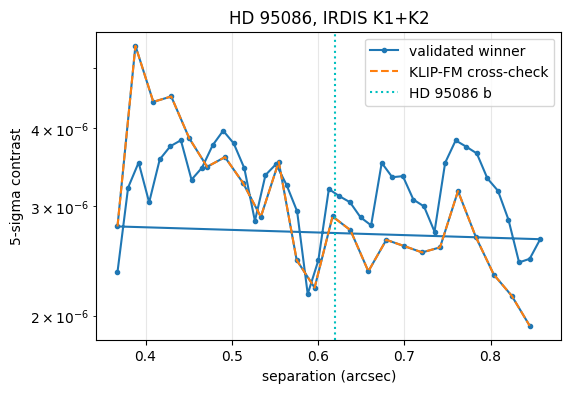

In [8]:
cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3, label="validated winner")
if r.fm_curve:
    plt.semilogy(r.fm_curve["r_as"], r.fm_curve["curve"], "--", label="KLIP-FM cross-check")
plt.axvline(0.62, color="c", ls=":", label="HD 95086 b"); plt.xlabel("separation (arcsec)"); plt.ylabel("5-sigma contrast")
# (the planet was passed as known= and is excluded from the noise rings, so it does not
#  inflate the limit at its own separation)
plt.legend(); plt.grid(alpha=.3); plt.title("HD 95086, IRDIS K1+K2");

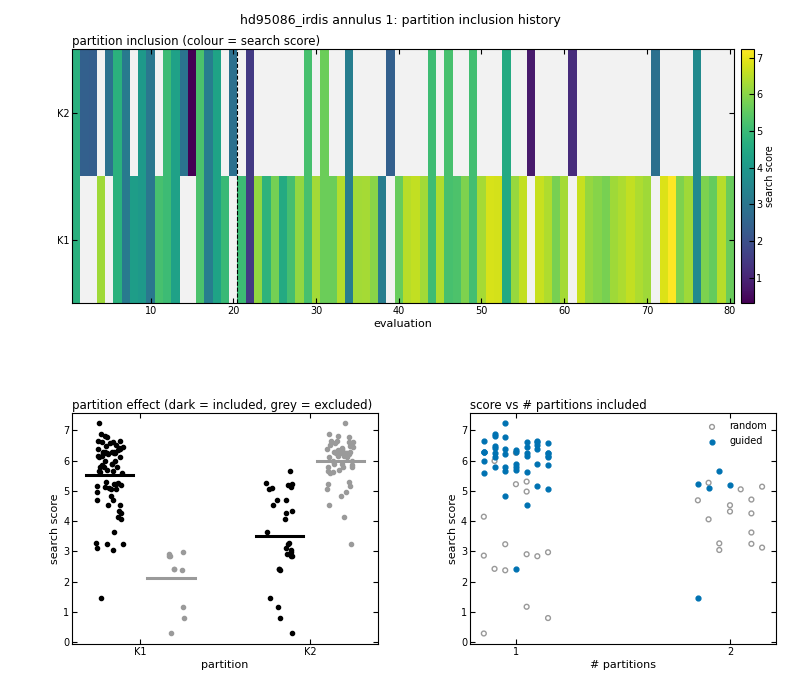

In [9]:
from IPython.display import Image
Image(filename=os.path.join(RUN_DIR, "annulus01", "partition_map.png"), width=800)

`annulus01/corner.pdf`, `importance.pdf` and `landscapes.pdf` show the sampled space per
partition; `annulus01/progress.gif` is the movie of this run.

## 5. Variations

* **More partitions** – add nights or epochs as more `Dataset`s; `--max-drop` /
  `make_space(max_drop=3)` gives the selection more slots when there are many.
* **One shared block** – `make_space(red, per_night=False)` tunes one parameter set for
  all partitions (fewer dimensions, faster convergence, less flexibility).
* **RDI** – give `load_cube(..., ref_cube=...)` a reference-star cube; the reducer then
  builds its KL basis from the references (`rdi_mode="rdi"`) or from references plus the
  angular-excluded science frames (`"ardi"`, default).  `datasets.fetch("sphere_sao206462")`
  has such a cube.
* **Terminal** –
  ```
  klip-tpe generic --cube hd95086_irdis_K1_cube.fits hd95086_irdis_K2_cube.fits --names K1 K2 \
      --angles hd95086_irdis_angles.fits --psf hd95086_irdis_K1_psf.fits hd95086_irdis_K2_psf.fits \
      --star-flux 2.91e9 2.66e9 --pxscale 0.01225 --lam 2.18e-6 --diam 8.2 --known 0.62 145 \
      --ann-edges 30 70 --n-iter 80 --n-init 20 --n-top 2 --n-valid 3 --run-dir runs/hd95086_cli --show
  ```